✅ Model loaded on cpu (missing=0, unexpected=0)


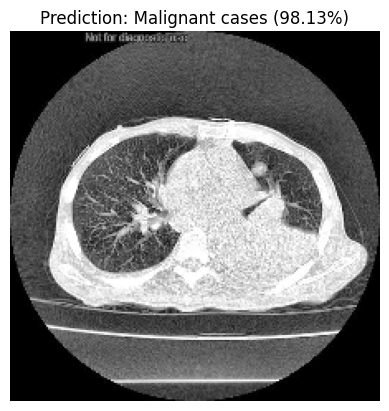

Class probabilities:
  Bengin cases: 1.87%
  Malignant cases: 98.13%
  Normal cases: 0.00%


In [ ]:

import os, sys, torch
import torch.nn.functional as F
from collections import OrderedDict
import cv2
import numpy as np
import matplotlib.pyplot as plt
from albumentations.pytorch import ToTensorV2
import albumentations as A

# --------------------------
# 🔧 Config
# --------------------------
PROJECT_ROOT = r"E:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer"
MODEL_PATH   = r"E:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer\client_1_checkpoints\best_model.pth"
#MODEL_PATH   = r"E:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer\Result\FLResult\fl_results_20250930_180627\last_global_model.pth"
IMG_PATH     = r"E:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer\DataSet\Lung-CT Scan\Malignant cases\Malignant (122).JPG"
DATA_DIR     = r"E:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer\DataSet\Lung-CT Scan"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = (224, 224)

# --------------------------
# 📦 Import Model
# --------------------------
sys.path.append(PROJECT_ROOT)
from models.model_factory import get_model

# Automatically get class names from dataset folders
class_names = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
idx_to_class = {i: c for i, c in enumerate(class_names)}

# --------------------------
# 🧠 Load Model
# --------------------------
model = get_model("customcnn", num_classes=len(class_names), pretrained=False, dropout_rate=0.5).to(DEVICE)

ckpt = torch.load(MODEL_PATH, map_location=DEVICE)
if "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
elif "state_dict" in ckpt:
    state_dict = ckpt["state_dict"]
else:
    state_dict = ckpt

clean_sd = OrderedDict()
for k, v in state_dict.items():
    clean_sd[k.replace("module.", "", 1) if k.startswith("module.") else k] = v

missing, unexpected = model.load_state_dict(clean_sd, strict=False)
print(f"✅ Model loaded on {DEVICE} (missing={len(missing)}, unexpected={len(unexpected)})")
model.eval()

# --------------------------
# 🧩 Image Preprocessing (same as dataset)
# --------------------------
def medical_preprocess_gray(image: np.ndarray) -> np.ndarray:
    image = cv2.resize(image, IMG_SIZE, interpolation=cv2.INTER_CUBIC)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image = clahe.apply(image)
    image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
    return image.astype(np.uint8)

transform = A.Compose([
    A.Resize(IMG_SIZE[1], IMG_SIZE[0]),
    A.Normalize(mean=[0.5], std=[0.5]),
    ToTensorV2()
])

def prepare_tensor(img_path: str):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"❌ Cannot load image: {img_path}")
    img = medical_preprocess_gray(img)
    tensor = transform(image=img)["image"].unsqueeze(0).to(DEVICE)
    return tensor, img

# --------------------------
# 🔮 Prediction
# --------------------------
with torch.no_grad():
    x, img_disp = prepare_tensor(IMG_PATH)
    outputs = model(x)
    probs = F.softmax(outputs, dim=1)[0].cpu().numpy()
    pred_idx = np.argmax(probs)
    pred_class = idx_to_class[pred_idx]
    confidence = probs[pred_idx] * 100

# --------------------------
# 🎯 Display Results
# --------------------------
plt.imshow(img_disp, cmap="gray")
plt.title(f"Prediction: {pred_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

print("Class probabilities:")
for name, p in zip(class_names, probs):
    print(f"  {name}: {p*100:.2f}%")


⚠️ load_state_dict(strict=False)
  Loaded cleanly ✅

✅ Prediction: pituitary_tumor
  glioma_tumor: 4.75%
  meningioma_tumor: 0.00%
  no_tumor  : 0.00%
  pituitary_tumor: 95.25%
💾 Saved Grad-CAM overlay -> gradcam_overlay.png


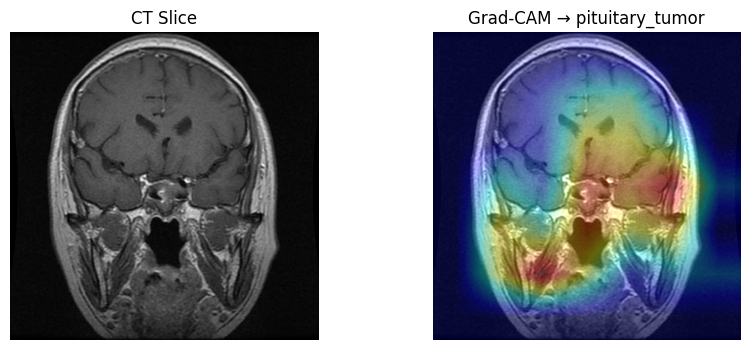

In [4]:
# =========================================================
# ✅ Robust loader + Prediction + Grad-CAM (grayscale CT)
#    - Handles checkpoints with: model_state_dict / state_dict / weights / model
#    - Strips "module." / "model." prefixes
#    - Loads with strict=False and prints missing/unexpected keys
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

from models.model_factory import get_model  # your factory (CustomCNN / ResNet50 / DenseNet121)

# ------------ CONFIG (edit these) ------------
MODEL_NAME  = "shufflenetv2"  # "customcnn" or "resnet50" or "densenet121"
MODEL_PATH  = r"D:\Masrafe\Masrafe extra\reasearch\Federated_brain\result_server\shufflenetv2\last_global_model.pth"
IMG_PATH    = r"client_3/pituitary_tumor/pituitary_tumor_client_3_9.jpg"

CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
IMG_SIZE    = 224
NORM_MEAN, NORM_STD = 0.5, 0.5
SAVE_OVERLAY_PATH = "gradcam_overlay.png"
# ---------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Build model ----------
model = get_model(MODEL_NAME, num_classes=len(CLASS_NAMES), pretrained=False).to(device)
model.eval()

# ---------- Robust checkpoint loader ----------
def load_checkpoint_flex(model: nn.Module, ckpt_path: str, device: torch.device):
    ckpt = torch.load(ckpt_path, map_location=device)

    # pick the actual state dict
    if isinstance(ckpt, dict):
        sd = None
        for key in ["model_state_dict", "state_dict", "weights", "model"]:
            if key in ckpt and isinstance(ckpt[key], dict):
                sd = ckpt[key]
                break
        if sd is None:
            # might already be a raw state dict mixed with metadata—heuristic:
            tensor_like = {k:v for k,v in ckpt.items() if isinstance(v, torch.Tensor)}
            sd = tensor_like if len(tensor_like) > 0 else ckpt
    else:
        sd = ckpt  # raw

    # strip common prefixes
    new_sd = {}
    for k, v in sd.items():
        if k.startswith("module."):
            k = k[len("module."):]
        if k.startswith("model."):
            k = k[len("model."):]
        new_sd[k] = v

    missing, unexpected = model.load_state_dict(new_sd, strict=False)
    print("⚠️ load_state_dict(strict=False)")
    if missing:
        print("  Missing keys:", missing)
    if unexpected:
        print("  Unexpected keys:", unexpected)
    if not missing and not unexpected:
        print("  Loaded cleanly ✅")

load_checkpoint_flex(model, MODEL_PATH, device)

# ---------- Preprocess grayscale CT ----------
def preprocess_gray(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image: {img_path}")
    orig = img.copy()
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    img = (img - NORM_MEAN) / (NORM_STD if NORM_STD != 0 else 1.0)
    t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float()  # [1,1,H,W]
    return orig, t

orig_u8, x = preprocess_gray(IMG_PATH)
x = x.to(device)

# ---------- Find last conv (for Grad-CAM) ----------
def find_last_conv(module: nn.Module):
    last = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    if last is None:
        raise RuntimeError("No Conv2d layer found. Grad-CAM needs a conv layer.")
    return last

target_layer = find_last_conv(model)

# ---------- Grad-CAM ----------
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.ha = target_layer.register_forward_hook(self._save_act)
        self.hg = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out.detach()          # [B,C,H,W]

    def _save_grad(self, module, gin, gout):
        self.gradients = gout[0].detach()        # [B,C,H,W]

    def generate(self, x: torch.Tensor, class_idx: int = None):
        self.model.zero_grad(set_to_none=True)
        x = x.clone().detach().requires_grad_(True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())
        score = logits[0, class_idx]
        score.backward(retain_graph=True)

        A = self.activations[0]                  # [C,H,W]
        dYdA = self.gradients[0]                 # [C,H,W]
        weights = torch.mean(dYdA, dim=(1,2))   # [C]
        cam = torch.relu(torch.sum(weights[:, None, None] * A, dim=0))  # [H,W]
        cam = cam.cpu().numpy().astype(np.float32)
        cam -= cam.min(); cam += 1e-12; cam /= cam.max()
        return cam

    def close(self):
        self.ha.remove(); self.hg.remove()

def overlay_on_gray(img_gray_u8: np.ndarray, cam: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    H, W = img_gray_u8.shape
    cam_r = cv2.resize(cam, (W, H))
    heat = cv2.applyColorMap((cam_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    base = cv2.cvtColor(img_gray_u8, cv2.COLOR_GRAY2RGB)
    return cv2.addWeighted(base, 1.0, heat, alpha, 0)

# ---------- Predict (fast, no grad) ----------
with torch.no_grad():
    logits = model(x)
    probs = F.softmax(logits, dim=1)[0].cpu().numpy()

pred_idx = int(np.argmax(probs))
pred_class = CLASS_NAMES[pred_idx]
print(f"\n✅ Prediction: {pred_class}")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:10s}: {probs[i]*100:.2f}%")

# ---------- Grad-CAM ----------
cam_engine = GradCAM(model, target_layer)
cam_map = cam_engine.generate(x, class_idx=pred_idx)
cam_engine.close()

overlay = overlay_on_gray(orig_u8, cam_map, alpha=0.35)
cv2.imwrite(SAVE_OVERLAY_PATH, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
print(f"💾 Saved Grad-CAM overlay -> {SAVE_OVERLAY_PATH}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(orig_u8, cmap='gray'); plt.title("CT Slice"); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(overlay); plt.title(f"Grad-CAM → {pred_class}"); plt.axis('off')
plt.show()


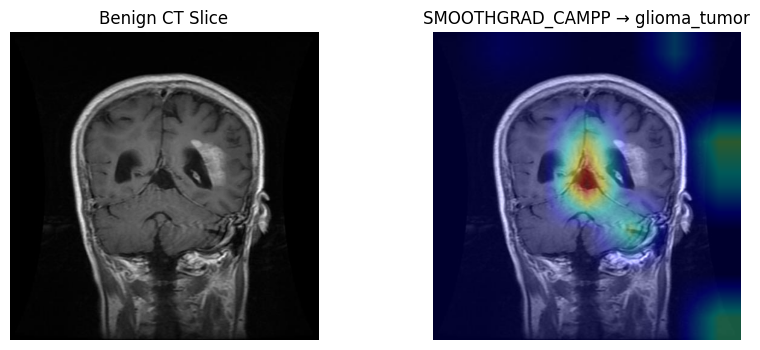

✅ Done: {
  "pred": "glioma_tumor",
  "overlay": "./xai_out\\glioma_tumor_client_3_4_smoothgrad_campp_overlay.png"
}


In [143]:
# ======================================================================
# 🧠 Advanced Grad-CAM Toolkit (Grad-CAM, Grad-CAM++, SmoothGrad-CAM++, GuidedBackprop)
#     - Works with CustomCNN / ResNet50 (1-channel CT)
#     - Auto target-layer finder
#     - Clean overlays & artifacts handling
# ======================================================================
import os, json, math, time, random
from typing import Optional, Tuple, Dict, List

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------- CONFIG (edit) -------
MODEL_NAME  = "shufflenetv2"  # "customcnn" or "resnet50" or "densenet121"
#MODEL_NAME  = "regnety400"
#MODEL_PATH  = r"D:\Masrafe\Masrafe extra\reasearch\Federated_brain\result_server\regy\last_global_model.pth"
MODEL_PATH  = r"D:\Masrafe\Masrafe extra\reasearch\Federated_brain\result_server\shufflenetv2\last_global_model.pth"
IMG_PATH    = r"client_3/glioma_tumor/glioma_tumor_client_3_4.jpg"

OUT_DIR     = "./xai_out"
CLASS_NAMES = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]
IMG_SIZE    = 224
NORM_MEAN, NORM_STD = 0.5, 0.5          # use your training norm
ALPHA = 0.35                             # overlay strength
METHOD = "smoothgrad_campp"              # "gradcam" | "gradcampp" | "smoothgrad_campp" | "guided_gradcam"
SMOOTHGRAD_SAMPLES = 10                  # for smoothgrad_campp
SMOOTHGRAD_NOISE_STD = 0.10              # fraction of input std
# -----------------------------

# your factory
from models.model_factory import get_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- robust checkpoint loader ----
def load_checkpoint_flex(model: nn.Module, path: str, device: torch.device):
    sd = torch.load(path, map_location=device)
    if isinstance(sd, dict):
        for k in ["model_state_dict", "state_dict", "weights", "model"]:
            if k in sd and isinstance(sd[k], dict):
                sd = sd[k]
                break
        # keep only tensor-like if mixed
        if not all(isinstance(v, torch.Tensor) for v in sd.values()):
            sd = {k:v for k,v in sd.items() if isinstance(v, torch.Tensor)} or sd
    new_sd = {}
    for k,v in sd.items():
        if k.startswith("module."): k = k[7:]
        if k.startswith("model."):  k = k[6:]
        new_sd[k] = v
    missing, unexpected = model.load_state_dict(new_sd, strict=False)
    if missing:   print("Missing:", missing)
    if unexpected:print("Unexpected:", unexpected)

# ---- build & load model ----
model = get_model(MODEL_NAME, num_classes=len(CLASS_NAMES), pretrained=False).to(device).eval()
load_checkpoint_flex(model, MODEL_PATH, device)

# ---- image io ----
def load_ct_gray(path: str, out_size: Tuple[int,int]=(IMG_SIZE, IMG_SIZE)):
    img_u8 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img_u8 is None:
        raise ValueError(f"Could not load: {path}")
    orig = img_u8.copy()
    img = cv2.resize(img_u8, out_size, interpolation=cv2.INTER_AREA).astype(np.float32)/255.0
    img = (img - NORM_MEAN) / (NORM_STD if NORM_STD!=0 else 1.0)
    x = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
    return orig, x

# ---- utils ----
def normalize01(a: np.ndarray):
    a = a.astype(np.float32)
    a -= a.min()
    a += 1e-12
    a /= a.max()
    return a

def overlay_on_gray(img_gray_u8: np.ndarray, heat: np.ndarray, alpha: float = 0.35):
    H,W = img_gray_u8.shape
    heat_r = cv2.resize(heat, (W, H))
    heatmap = cv2.applyColorMap((heat_r*255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    base = cv2.cvtColor(img_gray_u8, cv2.COLOR_GRAY2RGB)
    return cv2.addWeighted(base, 1.0, heatmap, alpha, 0)

# ---- target layer auto-pick (last Conv2d) ----
def find_last_conv(module: nn.Module):
    last = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    if last is None:
        raise RuntimeError("No Conv2d found for CAM.")
    return last

target_layer = find_last_conv(model)

# ---- Guided Backprop (for guided Grad-CAM) ----
class GuidedReLU(nn.Module):
    def forward(self, x):
        return torch.relu(x)

class GuidedBackprop:
    def __init__(self, model: nn.Module):
        self.model = model
        self.relu_handles = []
        self._register()

    def _register(self):
        def relu_backward_hook(module, grad_in, grad_out):
            # only pass positive gradients/activations
            return (torch.clamp(grad_in[0], min=0.0),)
        for m in self.model.modules():
            if isinstance(m, nn.ReLU):
                self.relu_handles.append(m.register_full_backward_hook(relu_backward_hook))

    def generate(self, x: torch.Tensor, class_idx: int):
        x = x.clone().requires_grad_(True)
        logits = self.model(x)
        score = logits[0, class_idx]
        self.model.zero_grad(set_to_none=True)
        score.backward(retain_graph=False)
        gb = x.grad.detach().squeeze(0).squeeze(0).cpu().numpy()  # [H,W]
        gb = np.abs(gb)
        gb = normalize01(gb)
        return gb

    def close(self):
        for h in self.relu_handles:
            h.remove()

# ---- CAM engines ----
class CAMBase:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model.eval()
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.ha = target_layer.register_forward_hook(self._save_act)
        self.hg = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations = out   # [B,C,H,W]
    def _save_grad(self, module, gin, gout):
        self.gradients = gout[0] # [B,C,H,W]

    def close(self):
        self.ha.remove(); self.hg.remove()

    def _post(self, cam: torch.Tensor):
        cam = torch.relu(cam).detach().cpu().numpy()
        return normalize01(cam)

class GradCAMEngine(CAMBase):
    def generate(self, x: torch.Tensor, class_idx: Optional[int] = None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1))
        score = logits[0, class_idx]
        score.backward(retain_graph=True)

        A = self.activations[0]             # [C,H,W]
        dYdA = self.gradients[0]            # [C,H,W]
        weights = dYdA.mean(dim=(1,2))      # [C]
        cam = (weights.view(-1,1,1) * A).sum(dim=0)  # [H,W]
        return self._post(cam)

class GradCAMPlusPlusEngine(CAMBase):
    def generate(self, x: torch.Tensor, class_idx: Optional[int] = None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1))
        score = logits[0, class_idx]
        score.backward(retain_graph=True)

        A = self.activations[0]             # [C,H,W]
        dY = self.gradients[0]              # [C,H,W]
        dY2 = dY ** 2
        dY3 = dY2 * dY

        eps = 1e-6
        sum_A = (A * dY3).sum(dim=(1,2))    # [C]
        denom = 2.0 * dY2 + sum_A[:, None, None]
        denom = torch.where(denom != 0, denom, torch.ones_like(denom)*eps)
        alpha = dY2 / denom                  # [C,H,W]
        weights = (alpha * torch.relu(dY)).sum(dim=(1,2))  # [C]
        cam = (weights.view(-1,1,1) * A).sum(dim=0)        # [H,W]
        return self._post(cam)

def smoothgrad_campp(model, target_layer, x: torch.Tensor, class_idx: int, samples=10, noise_std=0.1):
    engine = GradCAMPlusPlusEngine(model, target_layer)
    cams = []
    with torch.no_grad():
        base = x.clone().detach()
    for _ in range(samples):
        noise = torch.randn_like(base) * noise_std
        cam = engine.generate(base + noise, class_idx=class_idx)
        cams.append(cam)
    engine.close()
    cams = np.stack(cams, axis=0)
    cam = np.mean(cams, axis=0)
    return normalize01(cam)

# ---- Predict + Explain wrapper ----
def predict_and_explain(
    model: nn.Module,
    img_path: str,
    target_layer: nn.Module,
    method: str = "smoothgrad_campp",
    alpha: float = 0.35,
    smooth_samples: int = 10,
    smooth_noise: float = 0.1,
) -> Dict:
    os.makedirs(OUT_DIR, exist_ok=True)

    orig_u8, x = load_ct_gray(img_path)
    x = x.to(device)

    # predict
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1)[0].detach().cpu().numpy()
    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]

    # explain
    if method == "gradcam":
        engine = GradCAMEngine(model, target_layer)
        heat = engine.generate(x, class_idx=pred_idx)
        engine.close()
    elif method == "gradcampp":
        engine = GradCAMPlusPlusEngine(model, target_layer)
        heat = engine.generate(x, class_idx=pred_idx)
        engine.close()
    elif method == "smoothgrad_campp":
        heat = smoothgrad_campp(model, target_layer, x, pred_idx, samples=smooth_samples, noise_std=smooth_noise)
    elif method == "guided_gradcam":
        # Grad-CAM++ * GuidedBackprop fusion (Hadamard)
        engine = GradCAMPlusPlusEngine(model, target_layer)
        heat_cam = engine.generate(x, class_idx=pred_idx)
        engine.close()

        gb = GuidedBackprop(model)
        gb_map = gb.generate(x, class_idx=pred_idx)     # [H,W] in [0,1]
        gb.close()

        heat = normalize01(heat_cam * gb_map)
    else:
        raise ValueError("Unknown method")

    overlay = overlay_on_gray(orig_u8, heat, alpha=alpha)

    # save
    stem = os.path.splitext(os.path.basename(img_path))[0]
    np.save(os.path.join(OUT_DIR, f"{stem}_{method}_heat.npy"), heat)
    cv2.imwrite(os.path.join(OUT_DIR, f"{stem}_{method}_overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    with open(os.path.join(OUT_DIR, f"{stem}_probs.json"), "w") as f:
        json.dump({CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}, f, indent=2)

    # show
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(orig_u8, cmap='gray'); plt.title("Benign CT Slice"); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(overlay); plt.title(f"{method.upper()} → {pred_name}"); plt.axis('off')
    plt.show()

    return {
        "pred_idx": pred_idx,
        "pred_name": pred_name,
        "probs": {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))},
        "heat": heat,
        "overlay_path": os.path.join(OUT_DIR, f"{stem}_{method}_overlay.png"),
    }

# ==== RUN ON ONE IMAGE ====
res = predict_and_explain(
    model, IMG_PATH, target_layer,
    method=METHOD,
    alpha=ALPHA,
    smooth_samples=SMOOTHGRAD_SAMPLES,
    smooth_noise=SMOOTHGRAD_NOISE_STD
)
print("✅ Done:", json.dumps({"pred": res["pred_name"], "overlay": res["overlay_path"]}, indent=2))


e:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Prediction: Malignant cases | Probs: {'Bengin cases': 0.0487, 'Malignant cases': 0.9513, 'Normal cases': 0.0}


C:\Users\Rayhan\AppData\Local\Temp\ipykernel_18868\2936548801.py:153: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap('inferno')


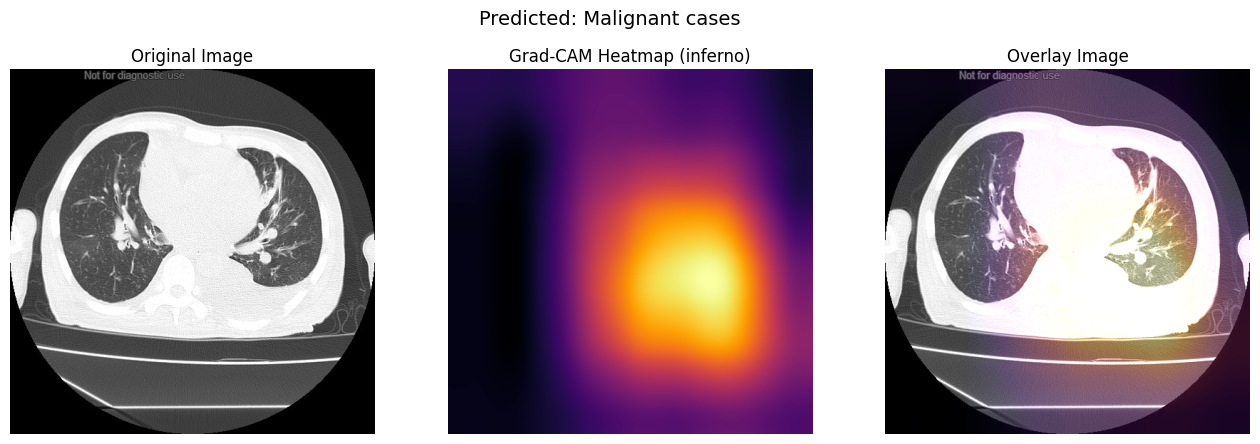

Saved:
 - Figure:  ./xai_figs\gradcam_triptych.png
 - Overlay: ./xai_figs\gradcam_overlay.png


In [1]:
# ============================================================
# 📸 Grad-CAM (Original | Heatmap[Inferno] | Overlay) Renderer
#    Works with your CustomCNN / ResNet50 (grayscale CT, 1-ch)
#    - Robust checkpoint loader
#    - Auto-picks last Conv2d as CAM target
#    - Saves figure and overlay PNGs
# ============================================================

import os, json
from typing import Tuple, Optional

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import cm

from models.model_factory import get_model  # uses your ResNet50 / CustomCNN

# ---------------- CONFIG (edit) ----------------
MODEL_NAME  = "hybridmodel"  # "customcnn" or "resnet50" or "hybridmodel"
MODEL_PATH  = r"Result/FLResult/HybridModel/last_global_model.pth"
IMG_PATH    = r"predicted_outputs/Lung-CTScan_Copy/Malignant cases/Malignant_cases_22.jpg" 

CLASS_NAMES  = ["Bengin cases", "Malignant cases", "Normal cases"]
IMG_SIZE     = 224
NORM_MEAN    = 0.5
NORM_STD     = 0.5
ALPHA        = 0.35                 # overlay blend
OUT_DIR      = "./xai_figs"
FIG_NAME     = "gradcam_triptych.png"
OVERLAY_NAME = "gradcam_overlay.png"
# ------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Robust checkpoint loader ----------
def load_checkpoint_flex(model: nn.Module, ckpt_path: str, device: torch.device):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict):
        sd = None
        for k in ["model_state_dict", "state_dict", "weights", "model"]:
            if k in ckpt and isinstance(ckpt[k], dict):
                sd = ckpt[k]; break
        if sd is None:
            # keep only tensor entries if mixed
            sd = {k:v for k,v in ckpt.items() if isinstance(v, torch.Tensor)} or ckpt
    else:
        sd = ckpt
    # strip prefixes
    new_sd = {}
    for k,v in sd.items():
        if k.startswith("module."): k = k[7:]
        if k.startswith("model."):  k = k[6:]
        new_sd[k] = v
    missing, unexpected = model.load_state_dict(new_sd, strict=False)
    if missing:   print("Missing keys:", missing)
    if unexpected: print("Unexpected keys:", unexpected)

# ---------- Build & load model ----------
model = get_model(MODEL_NAME, num_classes=len(CLASS_NAMES), pretrained=False).to(device).eval()
load_checkpoint_flex(model, MODEL_PATH, device)

# ---------- IO & preprocessing ----------
def load_ct_gray(path: str, out_size: Tuple[int,int]=(IMG_SIZE, IMG_SIZE)):
    img_u8 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img_u8 is None:
        raise ValueError(f"Could not load image: {path}")
    orig = img_u8.copy()
    img = cv2.resize(img_u8, out_size, interpolation=cv2.INTER_AREA).astype(np.float32)/255.0
    img = (img - NORM_MEAN) / (NORM_STD if NORM_STD != 0 else 1.0)
    x = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
    return orig, x

def normalize01(a: np.ndarray):
    a = a.astype(np.float32)
    a -= a.min()
    a += 1e-12
    a /= a.max()
    return a

# ---------- Target layer (last Conv2d) ----------
def find_last_conv(module: nn.Module):
    last = None
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            last = m
    if last is None:
        raise RuntimeError("No Conv2d found for Grad-CAM.")
    return last

target_layer = find_last_conv(model)

# ---------- Grad-CAM engine ----------
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model.eval()
        self.activations = None
        self.gradients = None
        self.ha = target_layer.register_forward_hook(self._hook_act)
        self.hg = target_layer.register_full_backward_hook(self._hook_grad)

    def _hook_act(self, module, inp, out):  self.activations = out
    def _hook_grad(self, module, gin, gout): self.gradients = gout[0]

    def generate(self, x: torch.Tensor, class_idx: Optional[int] = None) -> np.ndarray:
        # 💡 FIX: Explicitly enable gradient calculation for the input tensor.
        # This forces PyTorch to build a computation graph.
        x.requires_grad_(True)

        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())
        score = logits[0, class_idx]
        
        # You can also remove retain_graph=True as the graph is only used once here.
        score.backward() 

        A = self.activations[0]             # [C,H,W]
        dYdA = self.gradients[0]           # [C,H,W]
        weights = dYdA.mean(dim=(1,2))     # [C]
        cam = (weights.view(-1,1,1) * A).sum(dim=0)  # [H,W]
        cam = torch.relu(cam).detach().cpu().numpy()
        return normalize01(cam)

    def close(self):
        self.ha.remove(); self.hg.remove()

# ---------- Predict + Triptych render ----------
orig_u8, x = load_ct_gray(IMG_PATH)
x = x.to(device)

with torch.no_grad():
    logits = model(x)
    probs = F.softmax(logits, dim=1)[0].cpu().numpy()
pred_idx = int(np.argmax(probs))
pred_name = CLASS_NAMES[pred_idx]
print("Prediction:", pred_name, "| Probs:", {CLASS_NAMES[i]: float(f"{probs[i]:.4f}") for i in range(len(CLASS_NAMES))})

cam_engine = GradCAM(model, target_layer)
heat = cam_engine.generate(x, class_idx=pred_idx)  # [H,W] in [0,1]
cam_engine.close()

# Resize heat to original size & make overlay with inferno colormap
H, W = orig_u8.shape
heat_resized = cv2.resize(heat, (W, H), interpolation=cv2.INTER_CUBIC)

# Create inferno heatmap (RGB 0-255)
inferno = cm.get_cmap('inferno')
heat_rgb = (inferno(heat_resized)[:, :, :3] * 255).astype(np.uint8)

# Overlay (alpha blend) on gray CT
base_rgb = cv2.cvtColor(orig_u8, cv2.COLOR_GRAY2RGB)
overlay = cv2.addWeighted(base_rgb, 1.0, heat_rgb, ALPHA, 0)

# --------- Save outputs ----------
cv2.imwrite(os.path.join(OUT_DIR, OVERLAY_NAME), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
with open(os.path.join(OUT_DIR, "probs.json"), "w") as f:
    json.dump({CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}, f, indent=2)

# --------- Plot triptych ----------
plt.figure(figsize=(16,5))
plt.subplot(1,3,1); plt.imshow(orig_u8, cmap='gray'); plt.title("Original Image"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(heat_resized, cmap='inferno'); plt.title("Grad-CAM Heatmap (inferno)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(overlay); plt.title(f"Overlay Image"); plt.axis('off')
plt.suptitle(f"Predicted: {pred_name}", y=0.98, fontsize=14)

fig_path = os.path.join(OUT_DIR, FIG_NAME)
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved:\n - Figure:  {fig_path}\n - Overlay: {os.path.join(OUT_DIR, OVERLAY_NAME)}")


## Folder classify

In [6]:
# ============================================================
# 🗂 Folder-wise Lung CT Classifier (No Grad-CAM)
#    - Uses your model factory (get_model)
#    - Grayscale CT (1-ch), mean=0.5, std=0.5
#    - Robust checkpoint loader
#    - Copies/Moves images into predicted class folders
#    - Saves predictions.csv (and per-image JSON optionally)
# ============================================================

import os, csv, json
from typing import Tuple, Optional, List
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn

from models.model_factory import get_model  # your factory (resnet50/customcnn/hybrid)

# ---------------- CONFIG (edit) ----------------
MODEL_NAME   = "hybridmodel"  # "customcnn" or "resnet50" or "hybridmodel"
MODEL_PATH  = r"Result/FLResult/HybridModel/last_global_model.pth"

IN_DIR       = r"predicted_outputs/Lung-CTScan_Copy/Malignant cases/Malignant_cases_22.jpg"         # input images (searched recursively)
OUT_DIR      = r"E:\Python\Research\LungCancerFL\Federated_Learning_lung_cancer\predicted_outputs"   # output root

CLASS_NAMES  = ["Bengin", "Malignant", "Normal"]  # keep EXACT training order/spelling
IMG_SIZE     = 224
NORM_MEAN    = 0.5
NORM_STD     = 0.5

MODE         = "copy"       # "copy" or "move"
UNKNOWN_THR  = 0.0          # e.g., 0.55 → if max_prob<thr -> goes to "Unknown". 0.0 disables
SAVE_JSON    = False        # True: save per-image probs JSON next to destination file
CSV_NAME     = "predictions.csv"

VALID_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp", ".gif"}
# ------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Robust checkpoint loader ----------
def load_checkpoint_flex(model: nn.Module, ckpt_path: str, device: torch.device):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict):
        sd = None
        for k in ["model_state_dict", "state_dict", "weights", "model"]:
            if k in ckpt and isinstance(ckpt[k], dict):
                sd = ckpt[k]; break
        if sd is None:
            sd = {k:v for k,v in ckpt.items() if isinstance(v, torch.Tensor)} or ckpt
    else:
        sd = ckpt
    new_sd = {}
    for k,v in sd.items():
        if k.startswith("module."): k = k[7:]
        if k.startswith("model."):  k = k[6:]
        new_sd[k] = v
    missing, unexpected = model.load_state_dict(new_sd, strict=False)
    if missing:   print("Missing keys:", missing)
    if unexpected: print("Unexpected keys:", unexpected)

# ---------- Build & load model ----------
model = get_model(MODEL_NAME, num_classes=len(CLASS_NAMES), pretrained=False).to(device).eval()
load_checkpoint_flex(model, MODEL_PATH, device)

# ---------- IO & preprocessing ----------
def load_ct_gray_tensor(path: str, out_size: Tuple[int,int]=(IMG_SIZE, IMG_SIZE)) -> torch.Tensor:
    img_u8 = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img_u8 is None:
        raise ValueError(f"Could not load image: {path}")
    img = cv2.resize(img_u8, out_size, interpolation=cv2.INTER_AREA).astype(np.float32)/255.0
    img = (img - NORM_MEAN) / (NORM_STD if NORM_STD != 0 else 1.0)
    x = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]
    return x

def iter_images(root: str) -> List[Path]:
    root_p = Path(root)
    return [p for p in root_p.rglob("*") if p.is_file() and p.suffix.lower() in VALID_EXTS]

def ensure_dir(p: Path): p.mkdir(parents=True, exist_ok=True)

def move_or_copy(src: Path, dst: Path, mode: str = "copy"):
    ensure_dir(dst.parent)
    if mode == "move":
        src.replace(dst)
    else:
        # copy2 keeps modified time/metadata
        import shutil
        shutil.copy2(str(src), str(dst))

# ---------- Predict one ----------
@torch.no_grad()
def predict_probs(x: torch.Tensor) -> np.ndarray:
    x = x.to(device, non_blocking=True)
    logits = model(x)
    probs = F.softmax(logits, dim=1)[0].detach().cpu().numpy()
    return probs  # np.array [C]

# ---------- Main ----------
def main():
    in_paths = iter_images(IN_DIR)
    if not in_paths:
        print(f"[INFO] No images found in: {IN_DIR}")
        return

    # prepare output dirs
    for c in CLASS_NAMES: ensure_dir(Path(OUT_DIR) / c)
    if UNKNOWN_THR > 0.0:
        ensure_dir(Path(OUT_DIR) / "Unknown")

    # CSV
    csv_path = Path(OUT_DIR) / CSV_NAME
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        header = ["src_path", "dest_path", "pred_class", "max_prob", *[f"prob_{c}" for c in CLASS_NAMES]]
        writer.writerow(header)

        for src in in_paths:
            try:
                x = load_ct_gray_tensor(str(src))
            except Exception as e:
                print(f"[WARN] Skip unreadable: {src} ({e})")
                continue

            probs = predict_probs(x)
            pred_idx = int(np.argmax(probs))
            max_prob = float(probs[pred_idx])
            pred_name = CLASS_NAMES[pred_idx]

            # Unknown routing (optional)
            if UNKNOWN_THR > 0.0 and max_prob < UNKNOWN_THR:
                pred_name = "Unknown"

            dst = Path(OUT_DIR) / pred_name / src.name
            try:
                move_or_copy(src, dst, mode=MODE)
            except Exception as e:
                print(f"[WARN] Could not {MODE} {src} -> {dst} ({e})")
                continue

            writer.writerow([str(src), str(dst), pred_name, f"{max_prob:.6f}", *[f"{p:.6f}" for p in probs]])

            if SAVE_JSON:
                with open(dst.with_suffix(".json"), "w", encoding="utf-8") as jf:
                    json.dump({CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))},
                              jf, indent=2)

    print("\n✅ Classification complete.")
    print(f"Sorted images  -> {OUT_DIR}")
    print(f"Predictions CSV-> {csv_path}")
    print(f"Device: {device} | Model: {MODEL_NAME} | Mode: {MODE}")

if __name__ == "__main__":
    torch.set_grad_enabled(False)
    main()


[INFO] No images found in: predicted_outputs/Lung-CTScan_Copy/Malignant cases/Malignant_cases_22.jpg


In [4]:
#!/usr/bin/env python3
"""
Classify Lung CT images using your model factory (get_model -> 'customcnn').
- Fixed paths in code (no CLI / no prompts)
- Copies/Moves images into predicted class folders
- Saves predictions.csv with probabilities
"""

import csv
import shutil
from pathlib import Path
from typing import Dict, Any, Tuple, List, Optional

import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from torchvision import transforms
from tqdm import tqdm

# ===================== CONFIG (EDIT THESE) =====================
RAW_DIR   = Path(r"E:\luung data\niaz data\Lung-CT Scan-20250616T211158Z-1-001\Lung-CT Scan\Bengin cases")                       # Source images
OUT_DIR   = Path(r"E:\luung data\niaz data\Lung-CT Scan-20250616T211158Z-1-001\Lung-CT Scan\out")                # Destination root
MODEL_PATH = Path(r"Result/FLResult/fl_results_20251009_210344/last_global_model.pth")# Trained weights
MODEL_NAME = "customcnn"                                       # 'customcnn' per your factory
NUM_CLASSES = 3                                                # Must match CLASSES length
CLASSES   = ["Benign cases", "Malignant cases", "Normal cases"]                  # Training order
GRAYSCALE = True                                               # True if your CNN trained on 1-channel CT
IMG_SIZE  = 224                                                # Match training
MODE      = "copy"                                             # "copy" or "move"
UNKNOWN_THRESHOLD = 0.55                                       # 0.0 disables Unknown routing
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

# Normalization used during training — adjust if you used different stats
MEAN = [0.5] if GRAYSCALE else [0.485, 0.456, 0.406]
STD  = [0.5] if GRAYSCALE else [0.229, 0.224, 0.225]
# ===============================================================

# Import your model factory
from models.model_factory import get_model  # noqa: E402


def get_transform() -> transforms.Compose:
    t: List[Any] = []
    if GRAYSCALE:
        t.append(transforms.Grayscale(num_output_channels=1))
    else:
        t.append(transforms.Lambda(lambda im: im.convert("RGB")))
    t.extend([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD),
    ])
    return transforms.Compose(t)


def safe_open_image(p: Path) -> Optional[Image.Image]:
    try:
        img = Image.open(p)
        # Ensure expected channel mode
        if GRAYSCALE:
            img = img.convert("L")
        else:
            img = img.convert("RGB")
        _ = img.getbands()  # force load
        return img
    except (UnidentifiedImageError, OSError):
        return None


def list_images(root: Path) -> List[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp", ".gif"}
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in exts]


def ensure_dir(d: Path) -> None:
    d.mkdir(parents=True, exist_ok=True)


def move_or_copy(src: Path, dst: Path, mode: str = "copy") -> None:
    ensure_dir(dst.parent)
    if mode == "move":
        shutil.move(str(src), str(dst))
    else:
        shutil.copy2(str(src), str(dst))


def build_model() -> nn.Module:
    """
    Uses your factory exactly as provided:
      get_model(model_name: str, num_classes: int, pretrained: bool = True, dropout_rate: float = 0.5)
    For 'customcnn' your class likely ignores 'pretrained'/'dropout_rate', but we pass them safely.
    """
    model = get_model(model_name=MODEL_NAME, num_classes=NUM_CLASSES, pretrained=False, dropout_rate=0.0)
    return model.to(DEVICE).eval()


def _extract_state_dict(ckpt: Any) -> Dict[str, torch.Tensor]:
    """
    Accepts multiple common checkpoint formats:
      - {'state_dict': ...}
      - raw state_dict dict
      - model wrapped in 'model' key (adjust if needed)
    Also strips an initial 'module.' (DDP) prefix.
    """
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        state = ckpt["state_dict"]
    elif isinstance(ckpt, dict) and "model" in ckpt and isinstance(ckpt["model"], dict):
        state = ckpt["model"]
    elif isinstance(ckpt, dict):
        state = ckpt
    else:
        # If someone saved pure state_dict (rarely as a list/other), try to use as-is
        state = ckpt  # type: ignore

    # Remove DDP prefix if present
    cleaned = {}
    for k, v in state.items():
        if k.startswith("module."):
            cleaned[k[len("module."):]] = v
        else:
            cleaned[k] = v
    return cleaned


def load_weights(model: nn.Module, ckpt_path: Path) -> nn.Module:
    ckpt = torch.load(str(ckpt_path), map_location=DEVICE)
    state = _extract_state_dict(ckpt)
    # strict=False is safer if minor key name diffs exist
    model.load_state_dict(state, strict=False)
    model.eval()
    return model


@torch.no_grad()
def predict_one(model: nn.Module, img: Image.Image) -> Tuple[int, List[float]]:
    x = get_transform()(img).unsqueeze(0).to(DEVICE)  # [1, C, H, W]
    logits = model(x)
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().tolist()
    cls_idx = int(max(range(len(probs)), key=lambda i: probs[i]))
    return cls_idx, probs


def main() -> None:
    print("🫁 Classifying with your Custom CNN (via model_factory)...\n")

    if len(CLASSES) != NUM_CLASSES:
        print(f"[ERROR] NUM_CLASSES={NUM_CLASSES} but CLASSES has {len(CLASSES)} items.")
        return
    if not RAW_DIR.exists():
        print(f"[ERROR] RAW_DIR not found: {RAW_DIR}")
        return
    if not MODEL_PATH.exists():
        print(f"[ERROR] MODEL_PATH not found: {MODEL_PATH}")
        return

    # Build model & load weights
    model = build_model()
    model = load_weights(model, MODEL_PATH)

    # Prepare output structure
    for c in CLASSES:
        ensure_dir(OUT_DIR / c)
    unknown_name = "Unknown"
    if UNKNOWN_THRESHOLD > 0.0:
        ensure_dir(OUT_DIR / unknown_name)

    # Gather images
    images = list_images(RAW_DIR)
    if not images:
        print("[INFO] No images found.")
        return

    # CSV log
    csv_path = OUT_DIR / "predictions.csv"
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        header = ["src_path", "dest_path", "pred_class", "max_prob"] + [f"prob_{c}" for c in CLASSES]
        writer.writerow(header)

        for p in tqdm(images, desc="Classifying", unit="img"):
            img = safe_open_image(p)
            if img is None:
                continue

            cls_idx, probs = predict_one(model, img)
            max_prob = max(probs)
            pred_name = CLASSES[cls_idx]
            if UNKNOWN_THRESHOLD > 0.0 and max_prob < UNKNOWN_THRESHOLD:
                pred_name = unknown_name

            dest = OUT_DIR / pred_name / p.name
            try:
                move_or_copy(p, dest, mode=MODE)
            except Exception as e:
                print(f"[WARN] Could not {MODE} {p} -> {dest}: {e}")
                continue

            writer.writerow([str(p), str(dest), pred_name, f"{max_prob:.6f}", *[f"{v:.6f}" for v in probs]])

    print("\n✅ Done.")
    print(f"Sorted images -> {OUT_DIR}")
    print(f"Predictions CSV -> {csv_path}")
    print(f"Device: {DEVICE} | IMG_SIZE: {IMG_SIZE} | Grayscale: {GRAYSCALE}")


if __name__ == "__main__":
    torch.set_grad_enabled(False)
    main()


🫁 Classifying with your Custom CNN (via model_factory)...



Classifying: 100%|██████████| 1000/1000 [01:38<00:00, 10.11img/s]


✅ Done.
Sorted images -> E:\luung data\niaz data\Lung-CT Scan-20250616T211158Z-1-001\Lung-CT Scan\out
Predictions CSV -> E:\luung data\niaz data\Lung-CT Scan-20250616T211158Z-1-001\Lung-CT Scan\out\predictions.csv
Device: cpu | IMG_SIZE: 224 | Grayscale: True
